In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vencerlanz09/sea-animals-image-dataste")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sea-animals-image-dataste' dataset.
Path to dataset files: /kaggle/input/sea-animals-image-dataste


In [ ]:
import tensorflow as tf

# Check if GPU is available
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print(f"GPU detected: {len(gpu_available)} devices")
    for gpu in gpu_available:
        print(gpu)
else:
    print("No GPU found. TensorFlow will use CPU.")

GPU detected: 1 devices
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
import os
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf # Ensure tf is imported

# Path to the downloaded dataset
dataset_path = path # 'path' is the variable from the previous cell

# Define image size and batch size
IMG_SIZE = (224, 224) # InceptionV3 usually expects 299x299, but 224x224 is common
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2 # 20% for validation

# The dataset structure shows classes directly under dataset_path.
# We will use the main dataset_path and split it into training and validation.
# The previous 'if not os.path.exists' block and dummy data creation are no longer needed.

# Load training dataset using validation split
train_dataset = image_dataset_from_directory(
    dataset_path, # Use the main path where class folders are
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT, # Specify validation split
    subset='training', # This is the training subset
    seed=123 # For reproducible split
)

# Load validation dataset using validation split
validation_dataset = image_dataset_from_directory(
    dataset_path, # Use the main path where class folders are
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle validation set
    validation_split=VALIDATION_SPLIT, # Specify validation split
    subset='validation', # This is the validation subset
    seed=123 # For reproducible split
)

# Get number of classes from the training dataset
num_classes = len(train_dataset.class_names)
print(f"Number of classes detected: {num_classes}")
print(f"Class names: {train_dataset.class_names}")

# Preprocessing data for InceptionV3
def preprocess_for_inception(image, label):
    image = tf.cast(image, tf.float32) # Cast image to float32
    image = tf.keras.applications.inception_v3.preprocess_input(image)
    return image, label

train_dataset = train_dataset.map(preprocess_for_inception).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(preprocess_for_inception).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Load pre-trained InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))

# Freeze base layers
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x) # Use softmax for multi-class classification

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Found 13711 files belonging to 23 classes.
Using 10969 files for training.
Found 13711 files belonging to 23 classes.
Using 2742 files for validation.
Number of classes detected: 23
Class names: ['Clams', 'Corals', 'Crabs', 'Dolphin', 'Eel', 'Fish', 'Jelly Fish', 'Lobster', 'Nudibranchs', 'Octopus', 'Otter', 'Penguin', 'Puffers', 'Sea Rays', 'Sea Urchins', 'Seahorse', 'Seal', 'Sharks', 'Shrimp', 'Squid', 'Starfish', 'Turtle_Tortoise', 'Whale']
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 23,924,535 (91.26 MB)

 Trainable params: 2,121,751 (8.09 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
print(f"Listing contents of {dataset_path}:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]: # List only first 5 files in each directory for brevity
        print(f'{subindent}{f}')
    if len(files) > 5:
        print(f'{subindent}...(and {len(files) - 5} more files)')
    if not dirs and not files:
        print(f'{subindent}(empty)')


Listing contents of /kaggle/input/sea-animals-image-dataste:
sea-animals-image-dataste/
    Penguin/
        13441017033_5f20afed5c_o.jpg
        6814743888_d76f64e5e5_o.jpg
        7678547704_88ee08ec1d_b.jpg
        8474798677_0abda01a4a_o.jpg
        32902414928_2e8353fa26_o.jpg
        ...(and 477 more files)
    Clams/
        11127770525_eb487e975c_b.jpg
        7409907104_e68910d92d_o.jpg
        24659170965_ed13a20e49_o.jpg
        134917699_add44eaf73_o.jpg
        11587746256_6d931eb556_o.jpg
        ...(and 492 more files)
    Lobster/
        10508592885_c5d0dd4d2f_o.jpg
        20185221740_205d8ed735_o.jpg
        7898780506_b487483356_o.jpg
        8598643346_f6182a055a_o.jpg
        7721952750_ba4c1bd1df_o.jpg
        ...(and 494 more files)
    Otter/
        1755682925_53f103f317_o.jpg
        5614180288_ac2acf34ac_o.jpg
        8499384131_73b24d4249_o.jpg
        20669564526_6369dfe34a_b.jpg
        2176081409_b32f1d31d5_o.jpg
        ...(and 495 more files)
    Eel/


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 20 # You can adjust the number of epochs

# Callbacks to prevent overfitting and save the best model
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_inceptionv3_model.keras', monitor='val_accuracy', save_best_only=True)

print("Starting model training...")
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    callbacks=[early_stopping, model_checkpoint]
)
print("Training complete.")

Starting model training...
Epoch 1/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 84s 192ms/step - accuracy: 0.7025 - loss: 1.0200 - val_accuracy: 0.9533 - val_loss: 0.1762
Epoch 2/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.8031 - loss: 0.6584 - val_accuracy: 0.9712 - val_loss: 0.1163
Epoch 3/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.8346 - loss: 0.5487 - val_accuracy: 0.9774 - val_loss: 0.0944
Epoch 4/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.8595 - loss: 0.4691 - val_accuracy: 0.9810 - val_loss: 0.0846
Epoch 5/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.8821 - loss: 0.4049 - val_accuracy: 0.9814 - val_loss: 0.0808
Epoch 6/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - accuracy: 0.9008 - loss: 0.3504 - val_accuracy: 0.9807 - val_loss: 0.0824
Epoch 7/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.9214 - loss: 0.3042 - val_accuracy: 0.9818 - val_loss: 0.0837
Epoch 8/20
343/343 ━━━━━━━━━━━━━━━━━━━━ 29s 86ms/step - accura

In [ ]:
print("Evaluating model...")
loss, accuracy = model.evaluate(validation_dataset)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Load the best saved model and re-evaluate if available
# if os.path.exists('best_inceptionv3_model.keras'):
#     print("Loading the best saved model and re-evaluating...")
#     best_model = tf.keras.models.load_model('best_inceptionv3_model.keras')
#     loss_best, accuracy_best = best_model.evaluate(validation_dataset)
#     print(f"Best Model Validation Loss: {loss_best:.4f}")
#     print(f"Best Model Validation Accuracy: {accuracy_best:.4f}")

Evaluating model...
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9814 - loss: 0.0808
Validation Loss: 0.0808
Validation Accuracy: 0.9814


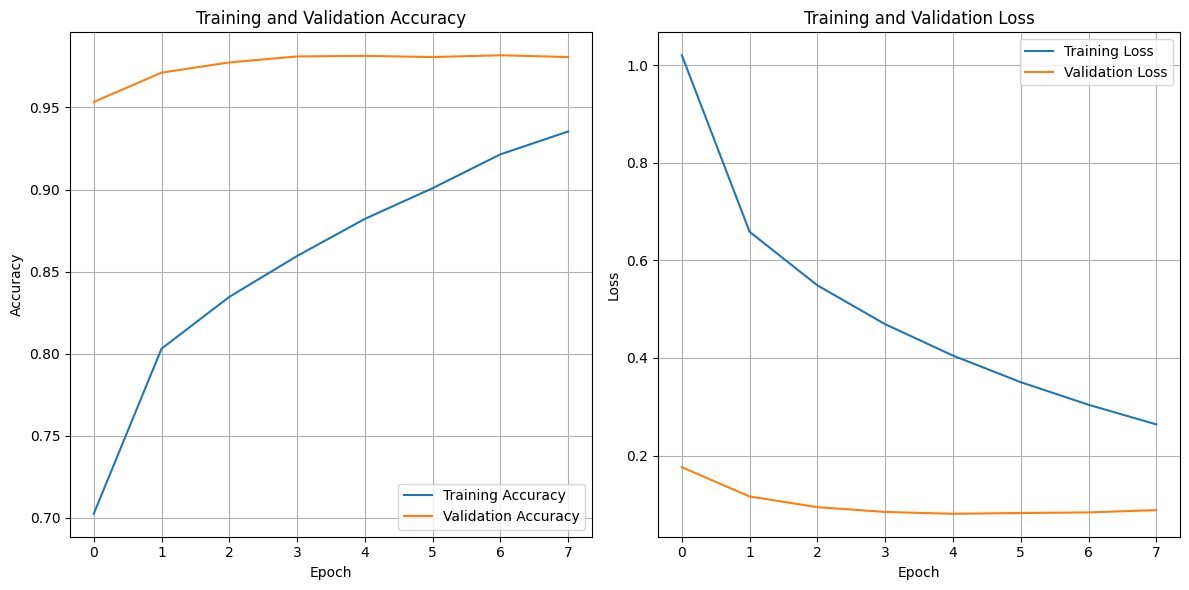

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()
